In [2]:
# ==========================================
# 1. IMPORTACIONES
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score


In [3]:
# ==========================================
# 2. CARGA Y LIMPIEZA TOTAL DE DATOS
# ==========================================
ruta = 'all_games.csv'
df_final = pd.read_csv(ruta)


In [4]:
# Limpieza de valores 'tbd' y conversión a numérico
df_final['user_review'] = pd.to_numeric(df_final['user_review'], errors='coerce')
df_final = df_final.dropna(subset=['meta_score', 'user_review'])


In [5]:
# Limpieza de nombres de plataforma
df_final['platform'] = df_final['platform'].str.strip()


In [6]:
# ==========================================
# 3. PREPARACIÓN Y ESCALADO
# ==========================================
# Seleccionamos las columnas para agrupar
features = df_final[['meta_score', 'user_review']]


In [7]:
# Es vital escalar para que K-Means funcione correctamente
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)


In [8]:
# ==========================================
# 4. ENTRENAMIENTO DEL MODELO (K-Means)
# ==========================================
# Entrenamos con k=3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_final['cluster'] = kmeans.fit_predict(features_scaled)


In [13]:
# Ver centroides reales
centroides = scaler.inverse_transform(kmeans.cluster_centers_)

centroides_df = pd.DataFrame(
    centroides,
    columns=['meta_score', 'user_review']
)

print("\n--- CENTROIDES REALES ---")
print(centroides_df)



--- CENTROIDES REALES ---
   meta_score  user_review
0   80.618318     7.899085
1   66.895467     6.831873
2   54.090687     4.589874


In [9]:
# ==========================================
# 5. MÉTODO PARA PROBAR EL MODELO (Asignar nuevos datos)
# ==========================================
def probar_segmentacion(meta_score_nuevo, user_review_nuevo):
    """
    Recibe puntuaciones de un juego nuevo y determina a qué cluster pertenece.
    """
    # 1. Crear el vector de entrada
    datos_nuevos = np.array([[meta_score_nuevo, user_review_nuevo]])
    
    # 2. ESCALAR los datos nuevos con el mismo transformador usado en el entrenamiento
    datos_escalados = scaler.transform(datos_nuevos)
    
    # 3. Predecir el cluster
    cluster_asignado = kmeans.predict(datos_escalados)[0]
    
    print(f"\n>>> Análisis de Segmentación:")
    print(f"    Entrada: MetaScore {meta_score_nuevo}, UserReview {user_review_nuevo}")
    print(f"    Segmento Asignado: Cluster {cluster_asignado}")
    
    # Explicación lógica del grupo (basado en centroides)
    if cluster_asignado == 0:
        print("    Perfil: Juego de recepción mixta o promedio.")
    elif cluster_asignado == 1:
        print("    Perfil: Obra Maestra / Blockbuster (Altas notas en ambos).")
    else:
        print("    Perfil: Posible Juego de Culto (Diferencia entre crítica y fans).")


In [10]:
# ==========================================
# 6. EVALUACIÓN Y VISUALIZACIÓN
# ==========================================
# Métrica de calidad técnica
score = silhouette_score(features_scaled, df_final['cluster'])
print(f"--- VALIDACIÓN TÉCNICA ---")
print(f"Coeficiente de Silueta: {score:.4f}")


--- VALIDACIÓN TÉCNICA ---
Coeficiente de Silueta: 0.3652


In [11]:
# Pruebas manuales con datos inventados
probar_segmentacion(95, 9.0)  # Debería ser Cluster de Éxito
probar_segmentacion(60, 5.0)  # Debería ser Cluster Promedio



>>> Análisis de Segmentación:
    Entrada: MetaScore 95, UserReview 9.0
    Segmento Asignado: Cluster 0
    Perfil: Juego de recepción mixta o promedio.

>>> Análisis de Segmentación:
    Entrada: MetaScore 60, UserReview 5.0
    Segmento Asignado: Cluster 2
    Perfil: Posible Juego de Culto (Diferencia entre crítica y fans).


/home/rusok/Descargas/ParaModulo14/20260502/paraJupyter/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/home/rusok/Descargas/ParaModulo14/20260502/paraJupyter/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


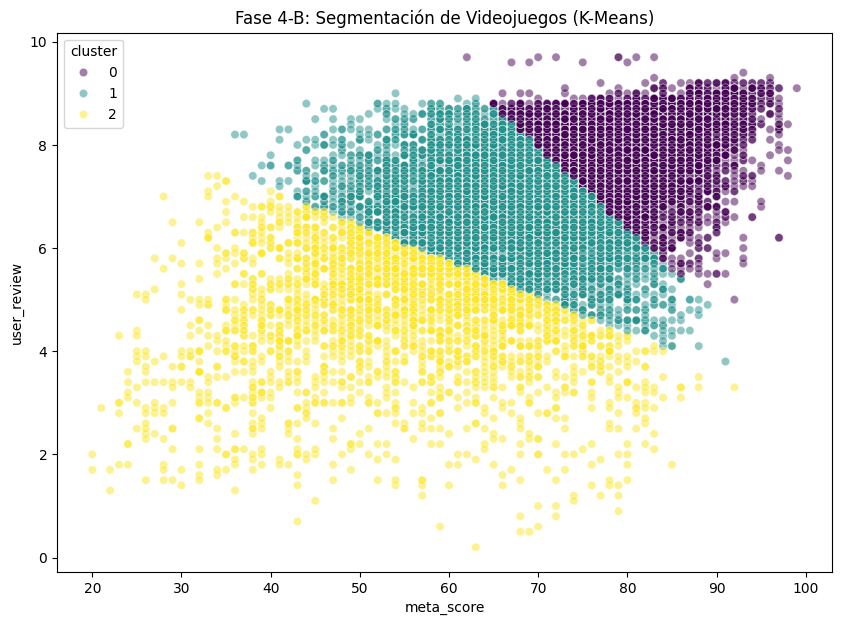

In [12]:
# Graficar resultados
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_final, x='meta_score', y='user_review', 
                hue='cluster', palette='viridis', alpha=0.5)
plt.title("Fase 4-B: Segmentación de Videojuegos (K-Means)")
plt.show()
